In [1]:
import torch

# ตรวจสอบและใช้งาน GPU ของชิป M4
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
print(f"รันโมเดลบน: {device}")

รันโมเดลบน: mps


In [2]:
import numpy as np
from scipy.io import loadmat
import gc
from torch.utils.data import DataLoader, TensorDataset
import torch

# 1. โหลดข้อมูล (ปล่อยให้เป็น Complex ก่อน)
path = '../DeepMIMO/DeepMIMO/DeepMIMO_dataset/SNR0dB_O1_60_Ant64/'
d1, d2, d3 = loadmat(path+'channel1.mat')['a'], loadmat(path+'channel2.mat')['b'], loadmat(path+'channel3.mat')['c']

# 2. รวมข้อมูล (ยังเป็น Complex อยู่)
data = np.concatenate((d1, d2, d3), axis=2).transpose(2, 0, 1)
del d1, d2, d3

# 3. แยก Real/Imag แล้วค่อยแปลงเป็น float32 (เพื่อไม่ให้ข้อมูลหาย!)
# ตรงนี้จะทำให้ได้ (Samples, 64, 64)
X_combined = np.concatenate((data.real, data.imag), axis=2).astype(np.float32)
X_flattened = np.reshape(X_combined, (data.shape[0], -1))

del data, X_combined
gc.collect()

# 4. Normalization แบบ Feature-wise (แม่นยำกว่า)
# ปรับสเกลแยกตามแต่ละ Antenna/Subcarrier
mean = np.mean(X_flattened, axis=0)
std = np.std(X_flattened, axis=0)
X_flattened = (X_flattened - mean) / (std + 1e-8)

# 5. โหลด Label
y = loadmat(path + 'DLCB_output.mat')['onehot_label'].astype(np.float32)

# 6. สร้าง Sequence
def create_sequences(data, labels, seq_length):
    num_samples = len(data) - seq_length
    X_seq = np.zeros((num_samples, seq_length, data.shape[1]), dtype=np.float32)
    y_seq = np.zeros((num_samples, labels.shape[1]), dtype=np.float32)
    for i in range(num_samples):
        X_seq[i] = data[i : i + seq_length]
        y_seq[i] = labels[i + seq_length - 1]
    return X_seq, y_seq

seq_length = 5
X_lstm, y_lstm = create_sequences(X_flattened, y, seq_length)
del X_flattened, y
gc.collect()

# 7. Sequential Split
split_idx = int(len(X_lstm) * 0.7)
X_train, X_test = X_lstm[:split_idx], X_lstm[split_idx:]
y_train, y_test = y_lstm[:split_idx], y_lstm[split_idx:]

train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test)), batch_size=128, shuffle=False)

print(f"Fixed LSTM Input shape: {X_train.shape}")

Fixed LSTM Input shape: (37423, 5, 4096)


In [3]:
import torch
import torch.nn as nn

class BeamPredictionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, n_beams, dropout_rate):
        super(BeamPredictionLSTM, self).__init__()
        # 1. บีบอัดจาก 4096 -> 256 เพื่อลด Noise ก่อนเข้า LSTM
        self.embedding = nn.Linear(input_size, 256)
        
        # 2. LSTM รับข้อมูลที่คลีนขึ้น (ขนาด 256)
        self.lstm = nn.LSTM(256, hidden_size, num_layers, batch_first=True, dropout=dropout_rate)
        
        self.fc = nn.Linear(hidden_size, n_beams)

    def forward(self, x):
        # x shape: (Batch, Seq, 4096)
        x = torch.relu(self.embedding(x)) # บีบอัดข้อมูลก่อน
        
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :]) # ใช้ข้อมูลจากจังหวะสุดท้ายมาทำนาย
        return out

In [4]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

model = BeamPredictionLSTM(4096, 512, 2, 64, 0.05).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total Trainable Params: {params}')

Total Trainable Params: 4759872


In [ ]:
epochs = 100
for epoch in range(epochs): # ลดเหลือ 50 เพื่อดูแนวโน้มก่อน
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, torch.max(labels, 1)[1])
        loss.backward()
        optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/50], Loss: {loss.item():.4f}')

In [45]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        _, actual = torch.max(labels.data, 1)
        total += labels.size(0)
        correct += (predicted == actual).sum().item()
        
print(f'Average Accuracy on SNR 0dB: {100 * correct / total:.2f}%')

Average Accuracy on SNR 0dB: 94.76%


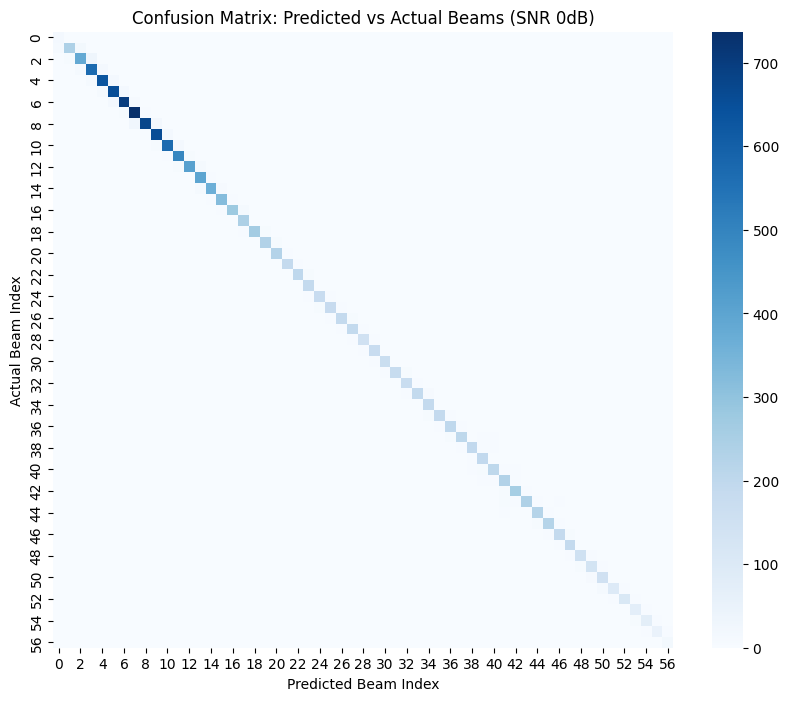

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# เก็บค่าผลลัพธ์ทั้งหมด
all_preds = []
all_actuals = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        _, actual = torch.max(labels, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_actuals.extend(actual.cpu().numpy())

# สร้าง Confusion Matrix
cm = confusion_matrix(all_actuals, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix: Predicted vs Actual Beams (SNR 0dB)')
plt.xlabel('Predicted Beam Index')
plt.ylabel('Actual Beam Index')
plt.show()

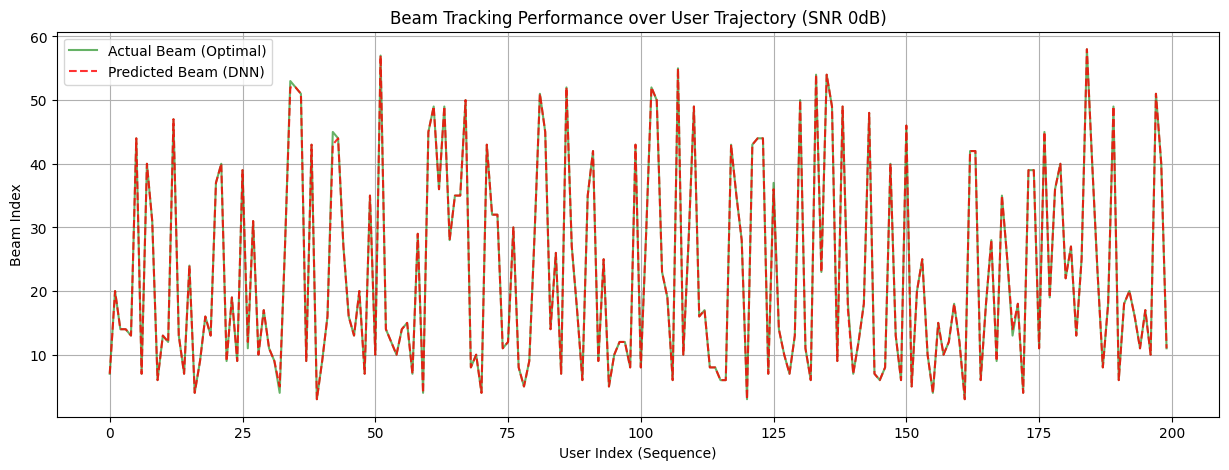

In [47]:
plt.figure(figsize=(15, 5))
plt.plot(all_actuals[:200], 'g-', label='Actual Beam (Optimal)', alpha=0.6)
plt.plot(all_preds[:200], 'r--', label='Predicted Beam (DNN)', alpha=0.8)
plt.title('Beam Tracking Performance over User Trajectory (SNR 0dB)')
plt.xlabel('User Index (Sequence)')
plt.ylabel('Beam Index')
plt.legend()
plt.grid(True)
plt.show()